# Week 1 - Problem Definition and Dataset Exploration

## Problem Statement

Cardiovascular diseases (CVDs) are one of the leading causes of death globally. Early detection and prediction of cardiovascular disease can significantly improve patient outcomes and reduce healthcare costs.

**Objective:** Build a Machine Learning model that predicts whether a patient has cardiovascular disease (binary classification) based on their medical and lifestyle attributes.

- **Dataset:** Cardiovascular Disease Dataset (Kaggle)
  - Source: https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset
- **Target Variable:** `cardio` — 1 if the patient has cardiovascular disease, 0 if not.
- **Type of Problem:** Binary Classification
- **Total Records:** 70,000 patient records
- **Total Features:** 12 input features + 1 target variable

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")

## Dataset Description

The dataset contains **70,000 records** with the following features:

| Feature | Type | Description |
|---|---|---|
| `id` | int | Unique patient identifier |
| `age` | int | Age of the patient **in days** |
| `gender` | int | Gender — 1: Female, 2: Male |
| `height` | int | Height in cm |
| `weight` | float | Weight in kg |
| `ap_hi` | int | Systolic blood pressure (upper value) |
| `ap_lo` | int | Diastolic blood pressure (lower value) |
| `cholesterol` | int | Cholesterol level — 1: Normal, 2: Above Normal, 3: Well Above Normal |
| `gluc` | int | Glucose level — 1: Normal, 2: Above Normal, 3: Well Above Normal |
| `smoke` | int | Smoking status — 0: No, 1: Yes |
| `alco` | int | Alcohol intake — 0: No, 1: Yes |
| `active` | int | Physical activity — 0: No, 1: Yes |
| `cardio` | int | **Target** — 0: No disease, 1: Has cardiovascular disease |

> **Note:** Age is stored in **days**, not years. To convert: age_years = age / 365. The patient age range is approximately 29 to 65 years.

In [3]:
df.head(5)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df.tail()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.0,120,80,2,1,0,0,1,0


In [5]:
df.shape

(70000, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["cardio"].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

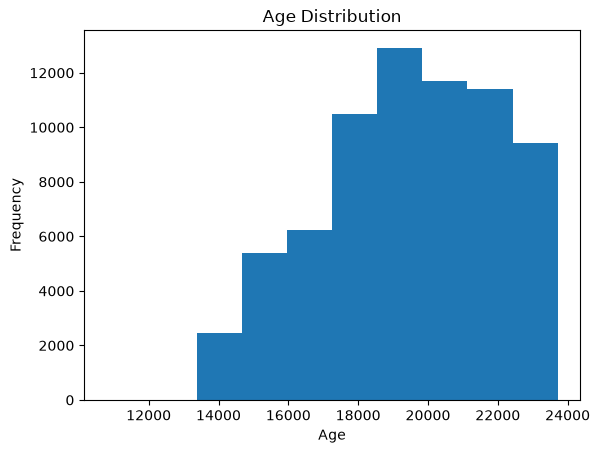

In [11]:
plt.hist(df["age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

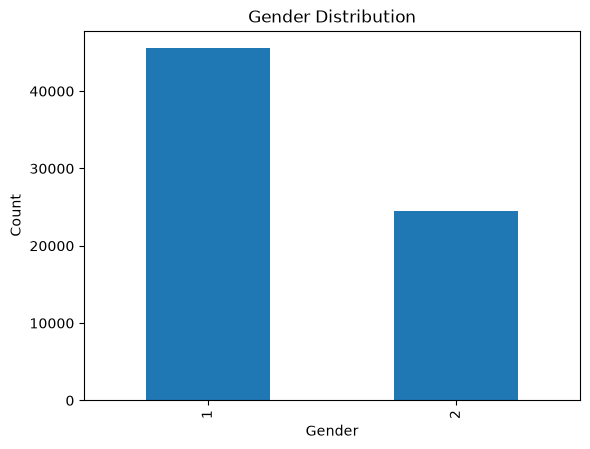

In [12]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

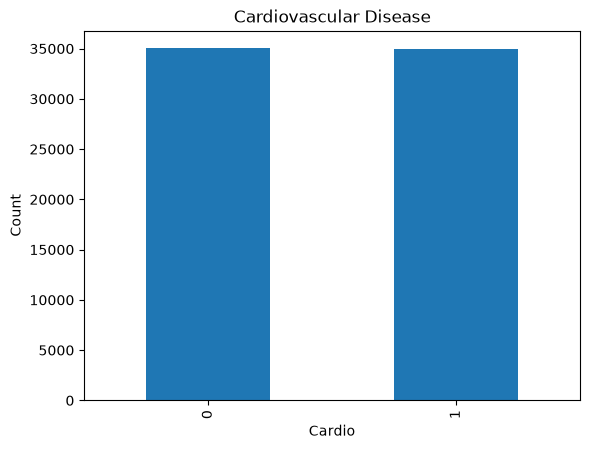

In [13]:
df["cardio"].value_counts().plot(kind="bar")
plt.title("Cardiovascular Disease")
plt.xlabel("Cardio")
plt.ylabel("Count")
plt.show()

In [14]:
df.groupby("cardio")["age"].mean()

cardio
0    18881.623711
1    20056.813031
Name: age, dtype: float64

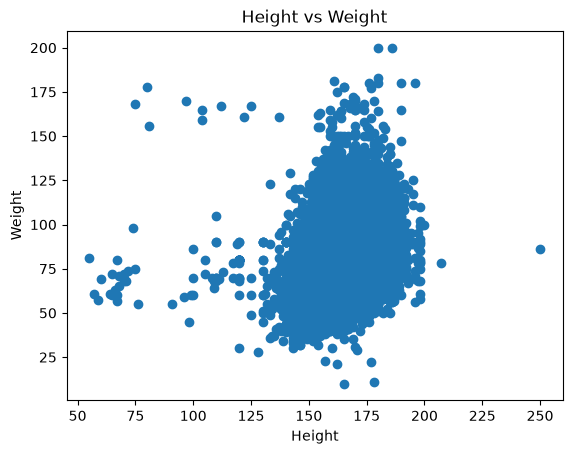

In [15]:
plt.scatter(df["height"], df["weight"])

plt.title("Height vs Weight")
plt.xlabel("Height")
plt.ylabel("Weight")

plt.show()

In [16]:
print("Minimum Age in Days:", df["age"].min())
print("Maximum Age in Days:", df["age"].max())

Minimum Age in Days: 10798
Maximum Age in Days: 23713


In [17]:
df.groupby("cardio")["weight"].mean()

cardio
0    71.592150
1    76.822368
Name: weight, dtype: float64

# Week 2 - Data Cleaning

## Why Clean?

Looking at `df.describe()`, we saw some clearly wrong values:
- `ap_hi` max = 16020 (impossible blood pressure)
- `ap_lo` min = -70 (negative blood pressure)
- `height` min = 55 cm (not a real adult)
- `weight` min = 10 kg (not realistic)

We remove these rows so the model doesn't learn from bad data.

In [18]:
print("Before Cleaning:", df.shape)

df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[df['ap_hi'] > df['ap_lo']]
df = df[(df['height'] >= 100) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

df = df.reset_index(drop=True)

print("After Cleaning :", df.shape)
print("Rows Removed   :", 70000 - len(df))

Before Cleaning: (70000, 13)
After Cleaning : (68639, 13)
Rows Removed   : 1361


# Week 3 - Feature Engineering

## What We Add

- `age_years` — age was stored in days, converting to years makes it human-readable
- `bmi` — Body Mass Index, calculated from height and weight. A known risk factor for cardiovascular disease.

In [19]:
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

print("BMI added. Sample:")
print(df[["height", "weight", "bmi"]].head())

BMI added. Sample:
   height  weight        bmi
0     168    62.0  21.967120
1     156    85.0  34.927679
2     165    64.0  23.507805
3     169    82.0  28.710479
4     156    56.0  23.011177


In [20]:
df["age_years"] = df["age"] / 365

x = df[['gender', 'height', 'weight', 'bmi', 'ap_hi', 'ap_lo',
        'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'age_years']]

y = df['cardio']

print("Features shape:", x.shape)
print("Target shape  :", y.shape)

Features shape: (68639, 12)
Target shape  : (68639,)


In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data :", x_test.shape)

Training data: (54911, 12)
Testing data : (13728, 12)


# Week 4 - Model Training

## Models We Train

1. **Random Forest** — ensemble of decision trees, each tree votes on the final prediction
2. **AdaBoost** — boosting algorithm that combines many weak learners into one strong model

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(x_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = rf.predict(x_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))

Accuracy : 0.7100087412587412
Precision: 0.709995517705065
Recall   : 0.6996466431095406
F1-Score : 0.7047830923248053


In [24]:
train_score = rf.score(x_train, y_train)
test_score = rf.score(x_test, y_test)

print("Train Score:", train_score)
print("Test Score :", test_score)
print("Score Gap  :", train_score - test_score)

Train Score: 0.9997450419770173
Test Score : 0.7100087412587412
Score Gap  : 0.28973630071827605


In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())
print("Score Spread:", cv_scores.max() - cv_scores.min())

CV Scores: [0.71119002 0.70934256 0.71116372 0.72108905 0.71070843]
Average CV Score: 0.7126987581493182
Score Spread: 0.011746494263340068


In [26]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(x_train, y_train)

print("AdaBoost trained successfully")

AdaBoost trained successfully


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_ada = ada.predict(x_test)

print("AdaBoost Accuracy :", accuracy_score(y_test, y_pred_ada))
print("AdaBoost Precision:", precision_score(y_test, y_pred_ada))
print("AdaBoost Recall   :", recall_score(y_test, y_pred_ada))
print("AdaBoost F1-score :", f1_score(y_test, y_pred_ada))

AdaBoost Accuracy : 0.7253787878787878
AdaBoost Precision: 0.7641608391608392
AdaBoost Recall   : 0.6435512367491166
AdaBoost F1-score : 0.6986892583120204


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

print("Data scaled — ready for Week 5 (Scratch LR)")

# Week 5 - Logistic Regression from Scratch

## Why from Scratch?

The SOP requires implementing at least one algorithm **without using a library**.

We build Logistic Regression using only `numpy`.

### How it works:
1. Initialize weights to zero
2. Compute `z = X * weights + bias`
3. Apply sigmoid: `1 / (1 + e^-z)` → gives probability between 0 and 1
4. Compute loss (binary cross entropy)
5. Update weights using gradient descent
6. Repeat for N iterations

In [30]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr         = learning_rate
        self.iterations = iterations
        self.weights    = None
        self.bias       = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias    = 0

        for _ in range(self.iterations):
            z    = np.dot(X, self.weights) + self.bias
            pred = self.sigmoid(z)

            dw = np.dot(X.T, (pred - y)) / n_samples
            db = np.sum(pred - y) / n_samples

            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

    def predict(self, X):
        z    = np.dot(X, self.weights) + self.bias
        prob = self.sigmoid(z)
        return (prob >= 0.5).astype(int)


print("Scratch class defined")

Scratch class defined


In [31]:
lr_scratch = LogisticRegressionScratch(learning_rate=0.1, iterations=1000)
lr_scratch.fit(x_train_scaled, y_train.values)

y_pred_scratch = lr_scratch.predict(x_test_scaled)

print("Scratch LR Accuracy :", accuracy_score(y_test, y_pred_scratch))
print("Scratch LR Precision:", precision_score(y_test, y_pred_scratch))
print("Scratch LR Recall   :", recall_score(y_test, y_pred_scratch))
print("Scratch LR F1-Score :", f1_score(y_test, y_pred_scratch))

Scratch LR Accuracy : 0.727782634032634
Scratch LR Precision: 0.7538640518530829
Scratch LR Recall   : 0.6678445229681979
Scratch LR F1-Score : 0.7082520103052541


# Week 6 - Model Evaluation

## Confusion Matrix and ROC Curve

- **Confusion Matrix** shows how many predictions were correct vs wrong
- **ROC Curve** shows model performance across all thresholds. Higher AUC = better model.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf  = rf.predict_proba(x_test)[:, 1]
y_prob_ada = ada.predict_proba(x_test)[:, 1]

fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf,  tpr_rf,  label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})")
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost      (AUC = {roc_auc_score(y_test, y_prob_ada):.2f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.show()

In [ ]:
print("Model Comparison Summary")
print("-" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("-" * 50)
print(f"{'Random Forest':<25} {accuracy_score(y_test, y_pred):>10.4f} {f1_score(y_test, y_pred):>10.4f}")
print(f"{'AdaBoost':<25} {accuracy_score(y_test, y_pred_ada):>10.4f} {f1_score(y_test, y_pred_ada):>10.4f}")
print("-" * 50)

# Week 7 - Hyperparameter Tuning

## What is Hyperparameter Tuning?

Instead of guessing the best settings for our model, we let the computer try multiple values and pick the best one.

For AdaBoost, the main hyperparameter is **n_estimators** (number of weak learners):
- **Small n_estimators** → fewer trees → faster but less accurate
- **Large n_estimators** → more trees → slower but potentially better

We use `GridSearchCV` with 5-fold cross-validation to find the best value.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100, 150, 200]}

grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(x_train, y_train)

print("Best n_estimators:", grid.best_params_['n_estimators'])
print("Best CV Score    :", round(grid.best_score_, 4))

In [ ]:
best_ada = grid.best_estimator_
y_pred_best = best_ada.predict(x_test)

print("Tuned AdaBoost Accuracy :", accuracy_score(y_test, y_pred_best))
print("Tuned AdaBoost Precision:", precision_score(y_test, y_pred_best))
print("Tuned AdaBoost Recall   :", recall_score(y_test, y_pred_best))
print("Tuned AdaBoost F1-Score :", f1_score(y_test, y_pred_best))